In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__results__.html
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_012_health_indicators_BRFSS2015.csv
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__resultx__.html
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__notebook__.ipynb
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__output__.json
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/custom.css


In [ ]:
df = pd.read_csv("/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

In [ ]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0.0,1.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,6.0
1,0.0,0.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,11.0,6.0,8.0
2,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,8.0
3,0.0,1.0,1.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,30.0,1.0,1.0,11.0,6.0,7.0
4,0.0,0.0,0.0,1.0,30.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,5.0,8.0


In [ ]:
df.shape

(70692, 22)

In [ ]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(1646)

In [ ]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

The dataset contains health and lifestyle information used to classify diabetes status. It contains 70,692 rows and 22 columns. The target variable is `Diabetes_binary`, where 0 represents non-diabetic individuals and 1 represents diabetic individuals.

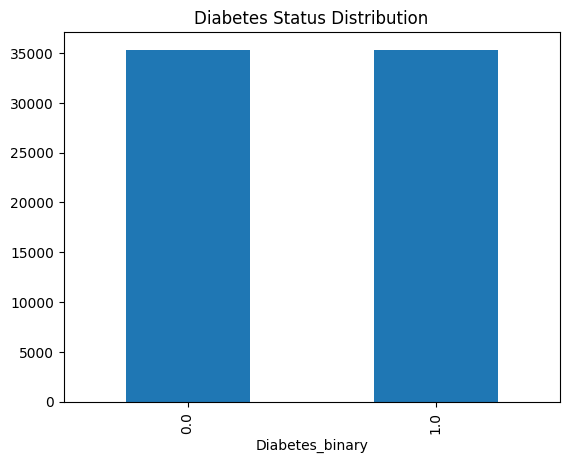

In [ ]:
df["Diabetes_binary"].value_counts().plot(kind="bar")
plt.title("Diabetes Status Distribution")
plt.show()

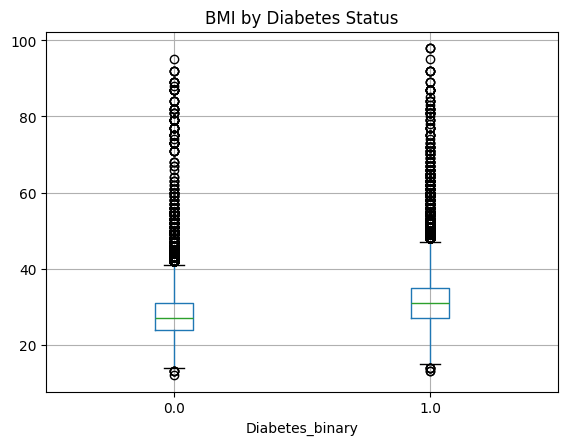

In [ ]:
df.boxplot(column="BMI", by="Diabetes_binary")
plt.title("BMI by Diabetes Status")
plt.suptitle("")
plt.show()

In [ ]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1:", f1_score(y_test, log_pred))

Logistic Regression
Accuracy: 0.7459509159063583
Precision: 0.7390347861955177
Recall: 0.7603621445749045
F1: 0.749546785664482


In [ ]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Random Forest
Accuracy: 0.7342810665535044
Precision: 0.7189317821258593
Recall: 0.7692742962229453
F1: 0.7432515547051186


In [ ]:
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

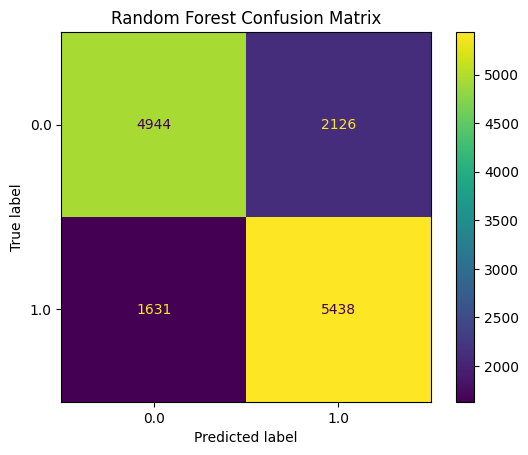

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

The Random Forest model relied most heavily on features such as BMI, general health, age, and other health indicators. These results describe the behavior of the model and should not be interpreted as proof that these variables cause diabetes.

This project uses survey data, so the results show associations rather than causation. The balanced dataset does not reflect the real-world prevalence of diabetes. This project is for educational purposes and is not a diagnostic tool.

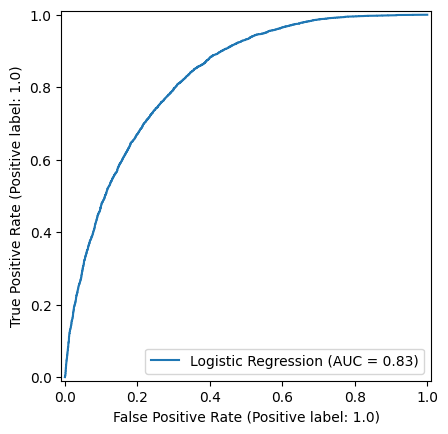

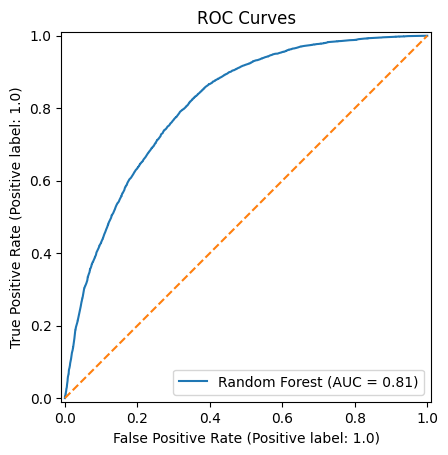

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.show()

In [ ]:
log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, log_prob))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

Logistic Regression ROC-AUC: 0.8265806858761175
Random Forest ROC-AUC: 0.8105371421688377


In [ ]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10)

BMI          0.170780
Age          0.125965
GenHlth      0.104884
Income       0.084148
HighBP       0.076430
PhysHlth     0.068690
Education    0.058038
MentHlth     0.052004
HighChol     0.041577
Smoker       0.029082
dtype: float64

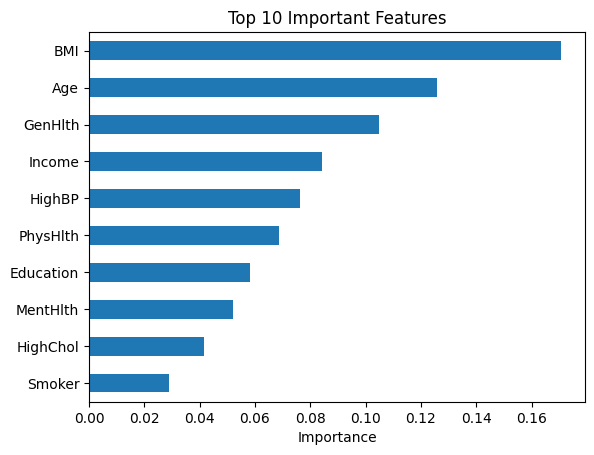

In [ ]:
importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

## Feature Importance

The Random Forest model relied more heavily on some health and lifestyle indicators than others. These feature-importance values describe how strongly the model used each variable for prediction.

They should not be interpreted as proof that these variables cause diabetes.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in [
    ("Logistic Regression", log_model),
    ("Random Forest", rf_model)
]:
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(name)
    print("Mean ROC-AUC:", scores.mean())
    print("Standard deviation:", scores.std())
    print()

Logistic Regression
Mean ROC-AUC: 0.8208673216056607
Standard deviation: 0.0045394451922521764

Random Forest
Mean ROC-AUC: 0.8099359631763672
Standard deviation: 0.004356823864135071



## Limitations

This project uses survey-based observational data, so the results show associations rather than causation.

The selected dataset is artificially balanced between diabetes and non-diabetes classes, so it does not represent the true prevalence of diabetes in the general population.

This project is intended for educational and portfolio purposes and should not be considered a medical diagnostic tool.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in [
    ("Logistic Regression", log_model),
    ("Random Forest", rf_model)
]:
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(name)
    print("Mean ROC-AUC:", scores.mean())
    print("Standard deviation:", scores.std())
    print()

Logistic Regression
Mean ROC-AUC: 0.8208673216056607
Standard deviation: 0.0045394451922521764

Random Forest
Mean ROC-AUC: 0.8099360976323162
Standard deviation: 0.004356686286387355



In [ ]:
log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.745951,0.739035,0.760362,0.749547,0.826581
1,Random Forest,0.734281,0.718932,0.769274,0.743252,0.810537


## Results

Logistic Regression and Random Forest were evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and five-fold stratified cross-validation.

Logistic Regression achieved an accuracy of 0.746, precision of 0.739, recall of 0.760, F1-score of 0.750, and ROC-AUC of 0.827. Random Forest achieved an accuracy of 0.734, precision of 0.719, recall of 0.769, F1-score of 0.743, and ROC-AUC of 0.811.

Five-fold cross-validation showed a mean ROC-AUC of 0.821 ± 0.005 for Logistic Regression and 0.810 ± 0.004 for Random Forest. Overall, Logistic Regression showed slightly better performance in terms of accuracy, precision, F1-score, and ROC-AUC, while Random Forest achieved slightly higher recall.

These findings indicate that both models were able to distinguish between diabetic and non-diabetic individuals using the available health and lifestyle indicators, with Logistic Regression showing slightly stronger overall predictive performance in this dataset.

## Conclusion

This project investigated whether routinely collected health and lifestyle indicators could be used to classify diabetes status using machine learning.

Logistic Regression and Random Forest were trained and evaluated using multiple performance metrics and five-fold stratified cross-validation. Logistic Regression showed slightly better overall performance, achieving a higher accuracy, F1-score, and ROC-AUC, while Random Forest produced slightly higher recall.

The results suggest that routinely collected health and lifestyle variables contain useful information for diabetes-status classification. Feature-importance analysis from the Random Forest model also showed that variables such as BMI, age, general health, income, and high blood pressure were among the features most strongly used for prediction.

However, these results represent predictive associations within this dataset and should not be interpreted as evidence that these variables directly cause diabetes. The model is intended for educational and portfolio purposes and is not a clinical diagnostic system.